# Heart Disease Prediction using Machine Learning

## Dataset Description

The dataset used in this project is the Heart Disease Dataset.

The objective of the dataset is to predict whether a patient has heart disease based on clinical and demographic attributes.

Target variable:

- 0 = No Heart Disease
- 1 = Heart Disease

The dataset contains medical information such as age, sex, blood pressure, cholesterol level, chest pain type and other diagnostic measurements.

## Dataset Source

The dataset was obtained from:

https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset

Accessed: June 2026

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_validate, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, silhouette_score, adjusted_rand_score,
    roc_auc_score, roc_curve, normalized_mutual_info_score, make_scorer
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.inspection import permutation_importance

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam


## Load Dataset

In [2]:
df = pd.read_csv("../dataset/heart.csv")

display(df.head())

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


Rows: 1025
Columns: 14


## Feature Description

| Feature | Description |
|---|---|
| age | Age of the patient |
| sex | Gender of the patient |
| cp | Chest pain type |
| trestbps | Resting blood pressure |
| chol | Serum cholesterol level |
| fbs | Fasting blood sugar |
| restecg | Resting electrocardiographic results |
| thalach | Maximum heart rate achieved |
| exang | Exercise-induced angina |
| oldpeak | ST depression induced by exercise |
| slope | Slope of the peak exercise ST segment |
| ca | Number of major vessels |
| thal | Thalassemia |
| target | Heart disease diagnosis |

# Exploratory Data Analysis (EDA)

This section summarizes the dataset before model training. It checks dataset dimensions, feature data types, missing values, descriptive statistics, class balance and key feature relationships. The generated EDA artifacts are saved in `ml/results` for reproducibility.

In [ ]:
import os

os.makedirs("../results", exist_ok=True)

print("Dataset shape:", df.shape)

feature_types_df = pd.DataFrame({
    "Feature": df.columns,
    "Data Type": df.dtypes.astype(str).values,
    "Non-Null Count": df.notnull().sum().values,
    "Missing Values": df.isnull().sum().values,
    "Missing Percentage": (df.isnull().mean() * 100).round(2).values
})

descriptive_stats_df = df.describe().T.reset_index().rename(columns={"index": "Feature"})

eda_summary_df = feature_types_df.merge(
    descriptive_stats_df,
    on="Feature",
    how="left"
)

eda_summary_df.to_csv("../results/eda_summary.csv", index=False)

display(feature_types_df)
display(descriptive_stats_df)

missing_values_df = feature_types_df[["Feature", "Missing Values", "Missing Percentage"]]
display(missing_values_df)

correlation_matrix = df.corr(numeric_only=True)
target_correlations = correlation_matrix["target"].drop("target").sort_values(
    key=lambda values: values.abs(),
    ascending=False
)

display(target_correlations.head(10).reset_index().rename(
    columns={"index": "Feature", "target": "Correlation with Target"}
))

plt.figure(figsize=(12, 9))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig("../results/correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="target", hue="target", palette="Set2", legend=False)
plt.xlabel("Heart Disease Diagnosis")
plt.ylabel("Count")
plt.title("Class Distribution")
plt.xticks([0, 1], ["No Heart Disease", "Heart Disease"])
plt.tight_layout()
plt.savefig("../results/class_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="age", hue="target", kde=True, bins=20, palette="Set2")
plt.xlabel("Age")
plt.ylabel("Count")
plt.title("Age Distribution by Heart Disease Class")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="chol", hue="target", kde=True, bins=25, palette="Set2")
plt.xlabel("Cholesterol")
plt.ylabel("Count")
plt.title("Cholesterol Distribution by Heart Disease Class")
plt.tight_layout()
plt.show()


The correlation heatmap highlights linear relationships between features and the target variable. The table above ranks features by absolute correlation with heart disease diagnosis, making it easier to identify the strongest positive and negative relationships.

In this dataset, the strongest relationships with the target are led by `oldpeak`, `exang`, `cp`, `thalach`, `ca`, `slope`, `thal` and `sex`. Positive correlations, such as chest pain type (`cp`), maximum heart rate achieved (`thalach`) and ST-segment slope (`slope`), indicate that higher encoded values are associated with a higher occurrence of heart disease in the dataset. Negative correlations, such as ST depression (`oldpeak`), exercise-induced angina (`exang`), number of major vessels (`ca`) and thalassemia (`thal`), indicate that higher encoded values are associated with a lower occurrence of the positive target class under this dataset encoding.

The class distribution chart checks whether the target classes are reasonably balanced. The age and cholesterol distributions show how important patient attributes vary across the two diagnosis groups before model training.

## Dataset Overview

In [3]:
df.info()
display(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


## Missing Values

In [4]:
missing_values = df.isnull().sum()
missing_values

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

If all values are zero, this means no missing values were found in the dataset.

## Duplicate Rows

In [5]:
duplicate_rows = df.duplicated().sum()
print("Duplicate rows:", duplicate_rows)

if duplicate_rows > 0:
    df = df.drop_duplicates()
    print("Duplicates removed.")
    print("New dataset shape:", df.shape)

Duplicate rows: 723
Duplicates removed.
New dataset shape: (302, 14)


Duplicate rows were checked and removed if present.

## Outlier Analysis

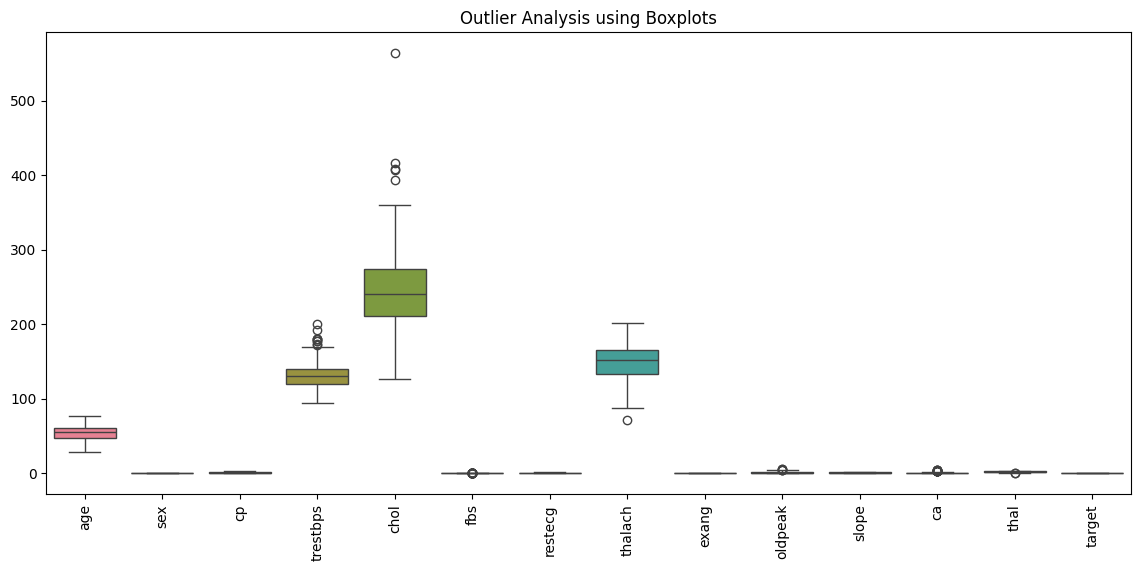

In [6]:
plt.figure(figsize=(14, 6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.title("Outlier Analysis using Boxplots")
plt.show()

Outliers were identified through boxplots.

Since this is a medical dataset, extreme values can represent valid patient measurements. Therefore, the outliers were retained instead of removed.

## Define Features and Target Variable

In [7]:
X = df.drop("target", axis=1)
y = df["target"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (302, 13)
Target shape: (302,)


## Train-Test Split

The dataset was divided into training and testing subsets using an 80/20 split.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (241, 13)
Testing set: (61, 13)


## Feature Scaling

Numerical features were standardized using `StandardScaler`.

This is particularly important for:

- KNN
- Logistic Regression
- Neural Networks

In [9]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Classical Classification Models

The following classical machine learning models were implemented:

- Logistic Regression
- Decision Tree
- K-Nearest Neighbors
- Random Forest

GridSearchCV was used to find the best hyperparameters for each model.

In [10]:
models = {
    "Logistic Regression": {
        "model": LogisticRegression(max_iter=1000),
        "params": {
            "C": [0.01, 0.1, 1, 10],
            "solver": ["liblinear", "lbfgs"]
        }
    },
    "Decision Tree": {
        "model": DecisionTreeClassifier(random_state=42),
        "params": {
            "max_depth": [3, 5, 10, None],
            "criterion": ["gini", "entropy"]
        }
    },
    "KNN": {
        "model": KNeighborsClassifier(),
        "params": {
            "n_neighbors": [3, 5, 7, 9],
            "weights": ["uniform", "distance"]
        }
    },
    "Random Forest": {
        "model": RandomForestClassifier(random_state=42),
        "params": {
            "n_estimators": [50, 100, 200],
            "max_depth": [3, 5, 10, None],
            "criterion": ["gini", "entropy"]
        }
    }
}

results = []
best_models = {}
model_roc_scores = {}

for model_name, model_info in models.items():
    print("Training:", model_name)

    grid = GridSearchCV(
        estimator=model_info["model"],
        param_grid=model_info["params"],
        cv=5,
        scoring="f1",
        n_jobs=-1
    )

    grid.fit(X_train_scaled, y_train)

    best_model = grid.best_estimator_
    best_models[model_name] = best_model

    y_pred = best_model.predict(X_test_scaled)
    y_score = best_model.predict_proba(X_test_scaled)[:, 1]
    model_roc_scores[model_name] = y_score

    results.append({
        "Model": model_name,
        "Best Parameters": grid.best_params_,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_score),
        "Confusion Matrix": confusion_matrix(y_test, y_pred)
    })

results_df = pd.DataFrame(results)
display(results_df)


Training: Logistic Regression
Training: Decision Tree
Training: KNN
Training: Random Forest


,Model,Best Parameters,Accuracy,Precision,Recall,F1-score,Confusion Matrix
0,Logistic Regression,"{'C': 0.01, 'solver': 'lbfgs'}",0.803279,0.783784,0.878788,0.828571,"[[20, 8], [4, 29]]"
1,Decision Tree,"{'criterion': 'entropy', 'max_depth': 3}",0.770492,0.743590,0.878788,0.805556,"[[18, 10], [4, 29]]"
2,KNN,"{'n_neighbors': 9, 'weights': 'uniform'}",0.803279,0.783784,0.878788,0.828571,"[[20, 8], [4, 29]]"
3,Random Forest,"{'criterion': 'entropy', 'max_depth': 3, 'n_es...",0.803279,0.800000,0.848485,0.823529,"[[21, 7], [5, 28]]"


## Feature Importance

Feature importance was calculated for the two interpretable classical models used in this notebook. Logistic Regression is interpreted through signed coefficients, where positive coefficients increase the predicted probability of heart disease and negative coefficients decrease it. Random Forest is interpreted through impurity-based feature importances, which rank features according to how much they contribute to decision-tree splits.

Because coefficients and tree importances are on different scales, both are normalized before creating the combined Top 10 feature ranking.

In [ ]:
import os
os.makedirs("../results", exist_ok=True)

feature_names = pd.Index(X.columns)

logistic_model = best_models["Logistic Regression"]
random_forest_model = best_models["Random Forest"]

lr_coefficients = logistic_model.coef_[0]
lr_abs_importance = np.abs(lr_coefficients)
rf_importance = random_forest_model.feature_importances_

lr_normalized = lr_abs_importance / lr_abs_importance.max() if lr_abs_importance.max() != 0 else lr_abs_importance
rf_normalized = rf_importance / rf_importance.max() if rf_importance.max() != 0 else rf_importance

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Logistic Regression Coefficient": lr_coefficients,
    "Logistic Regression Absolute Importance": lr_abs_importance,
    "Logistic Regression Direction": np.where(
        lr_coefficients > 0,
        "Increases predicted risk",
        np.where(lr_coefficients < 0, "Decreases predicted risk", "Neutral")
    ),
    "Random Forest Importance": rf_importance,
    "Combined Importance": (lr_normalized + rf_normalized) / 2
})

feature_importance_df["Logistic Regression Rank"] = feature_importance_df[
    "Logistic Regression Absolute Importance"
].rank(method="dense", ascending=False).astype(int)
feature_importance_df["Random Forest Rank"] = feature_importance_df[
    "Random Forest Importance"
].rank(method="dense", ascending=False).astype(int)

feature_importance_df = feature_importance_df.sort_values(
    by="Combined Importance",
    ascending=False
).reset_index(drop=True)
feature_importance_df.insert(0, "Overall Rank", np.arange(1, len(feature_importance_df) + 1))

top_10_features = feature_importance_df.head(10)

feature_importance_df.to_csv("../results/feature_importance.csv", index=False)

display(top_10_features)

plot_df = top_10_features.sort_values("Combined Importance", ascending=True)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=plot_df,
    x="Combined Importance",
    y="Feature",
    color="#2f6f8f"
)
plt.xlabel("Combined Normalized Importance")
plt.ylabel("Feature")
plt.title("Top 10 Most Important Heart Disease Risk Features")
plt.tight_layout()
plt.savefig("../results/feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

top_lr_positive = feature_importance_df.sort_values(
    "Logistic Regression Coefficient",
    ascending=False
).head(3)["Feature"].tolist()
top_lr_negative = feature_importance_df.sort_values(
    "Logistic Regression Coefficient",
    ascending=True
).head(3)["Feature"].tolist()
top_rf_features = feature_importance_df.sort_values(
    "Random Forest Importance",
    ascending=False
).head(5)["Feature"].tolist()

print("Strongest positive Logistic Regression risk signals:", top_lr_positive)
print("Strongest negative Logistic Regression risk signals:", top_lr_negative)
print("Highest ranked Random Forest features:", top_rf_features)

The Top 10 table highlights the features with the strongest combined signal across Logistic Regression and Random Forest. In this heart disease dataset, diagnostic and exercise-response variables such as chest pain type (`cp`), number of major vessels (`ca`), thalassemia (`thal`), ST depression (`oldpeak`), maximum heart rate (`thalach`), exercise-induced angina (`exang`) and ST-segment slope (`slope`) are expected to be among the most influential predictors.

For Logistic Regression, the sign of the coefficient explains direction: positive coefficients push the prediction toward higher heart disease risk, while negative coefficients push it toward lower risk. For Random Forest, the ranking shows which variables most often reduce uncertainty in the tree ensemble; it does not provide a positive or negative direction by itself. The saved CSV and chart provide a reproducible record of these model interpretation results.

## Prediction Explainability

SHAP is not required for this notebook because the same interpretability goal can be handled with permutation importance and model-specific local contributions. Global explainability is calculated using permutation importance, which measures how much model performance drops when each feature is randomly shuffled. Larger drops indicate features the model depends on more strongly.

Local explanations are generated for sample high-risk and low-risk patients using Logistic Regression coefficient contributions. The standardized patient feature value is multiplied by the learned coefficient to estimate how much that feature pushes the log-odds toward higher or lower predicted heart disease risk.

In [ ]:
import os

os.makedirs("../results", exist_ok=True)

explainability_model = best_models["Logistic Regression"]

permutation_results = permutation_importance(
    explainability_model,
    X_test_scaled,
    y_test,
    n_repeats=30,
    random_state=42,
    scoring="f1"
)

permutation_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Permutation Importance Mean": permutation_results.importances_mean,
    "Permutation Importance Std": permutation_results.importances_std
}).sort_values(by="Permutation Importance Mean", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=permutation_importance_df.head(10),
    x="Permutation Importance Mean",
    y="Feature",
    color="#2f6f8f"
)
plt.xlabel("Mean F1-score Decrease After Permutation")
plt.ylabel("Feature")
plt.title("Global Prediction Explainability - Permutation Importance")
plt.tight_layout()
plt.savefig("../results/shap_summary.png", dpi=300, bbox_inches="tight")
plt.show()

display(permutation_importance_df)

patient_probabilities = explainability_model.predict_proba(X_test_scaled)[:, 1]
high_risk_position = int(np.argmax(patient_probabilities))
low_risk_position = int(np.argmin(patient_probabilities))


def local_logistic_explanation(patient_position):
    patient_values_scaled = X_test_scaled[patient_position]
    contributions = patient_values_scaled * explainability_model.coef_[0]
    probability = patient_probabilities[patient_position]
    prediction_label = "High Risk" if probability >= 0.5 else "Low Risk"

    local_df = pd.DataFrame({
        "Feature": X.columns,
        "Patient Value": X_test.iloc[patient_position].values,
        "Contribution": contributions,
        "Absolute Contribution": np.abs(contributions)
    }).sort_values(by="Absolute Contribution", ascending=False)

    return prediction_label, probability, local_df


high_label, high_probability, high_explanation_df = local_logistic_explanation(high_risk_position)
low_label, low_probability, low_explanation_df = local_logistic_explanation(low_risk_position)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, title, probability, local_df in [
    (axes[0], f"High-Risk Sample (p={high_probability:.3f})", high_probability, high_explanation_df),
    (axes[1], f"Low-Risk Sample (p={low_probability:.3f})", low_probability, low_explanation_df)
]:
    plot_df = local_df.head(8).sort_values("Contribution")
    colors = ["#c44e52" if value > 0 else "#4c72b0" for value in plot_df["Contribution"]]
    ax.barh(plot_df["Feature"], plot_df["Contribution"], color=colors)
    ax.axvline(0, color="black", linewidth=1)
    ax.set_title(title)
    ax.set_xlabel("Contribution to Heart Disease Risk Log-Odds")
    ax.set_ylabel("Feature")

plt.suptitle("Local Prediction Explanations for Sample Patients")
plt.tight_layout()
plt.savefig("../results/shap_patient_example.png", dpi=300, bbox_inches="tight")
plt.show()

print("High-risk sample prediction:", high_label, "with probability", round(high_probability, 4))
print("Features pushing the high-risk prediction most strongly:")
display(high_explanation_df.head(8))

print("Low-risk sample prediction:", low_label, "with probability", round(low_probability, 4))
print("Features pushing the low-risk prediction most strongly:")
display(low_explanation_df.head(8))


The global permutation plot shows which features most affect model performance when their relationship with the target is disrupted. These are the features the model relies on most for overall classification quality.

The local patient plots explain individual predictions. Red bars push the prediction toward higher heart disease risk, while blue bars push it toward lower risk. The size of each bar shows the strength of that feature contribution for the selected patient. A high-risk prediction is produced when the combined positive evidence is strong enough to push the predicted probability above the classification threshold; a low-risk prediction occurs when protective or lower-risk contributions dominate.

These explanations are model interpretation aids. They describe how the trained model uses the input features and should not be treated as medical advice.

## Confusion Matrices for Classical Models

Confusion matrices were generated to evaluate correct and incorrect predictions for each model.

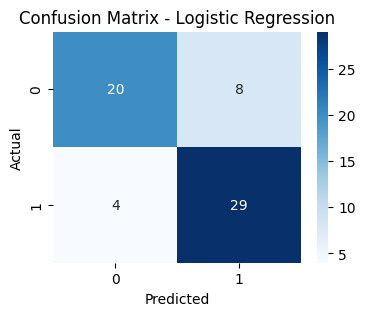

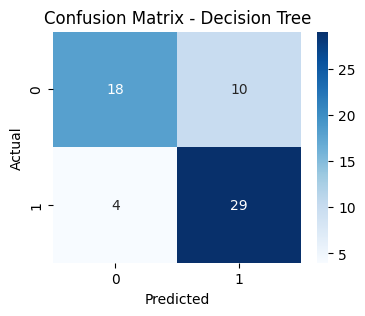

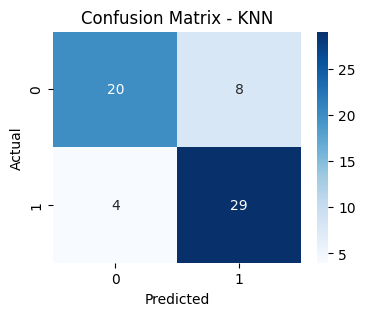

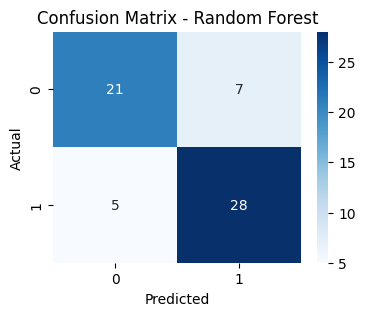

In [11]:
for model_name, model in best_models.items():
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# Feature Selection

`SelectKBest` was used to identify the most informative features.

The objective was to investigate whether reducing the number of features improves classification performance.

In [12]:
selector = SelectKBest(score_func=f_classif, k=8)

X_train_selected = selector.fit_transform(X_train_scaled, y_train)
X_test_selected = selector.transform(X_test_scaled)

selected_features = X.columns[selector.get_support()]
print("Selected features:")
print(list(selected_features))

Selected features:
['sex', 'cp', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


## Model Performance with Selected Features

In [13]:
feature_selection_results = []
best_feature_selection_models = {}
feature_selection_roc_scores = {}

for model_name, model_info in models.items():
    print("Training with selected features:", model_name)

    grid = GridSearchCV(
        estimator=model_info["model"],
        param_grid=model_info["params"],
        cv=5,
        scoring="f1",
        n_jobs=-1
    )

    grid.fit(X_train_selected, y_train)

    best_selected_model = grid.best_estimator_
    best_feature_selection_models[model_name] = best_selected_model

    y_pred = best_selected_model.predict(X_test_selected)
    y_score = best_selected_model.predict_proba(X_test_selected)[:, 1]
    feature_selection_roc_scores[model_name + " with Feature Selection"] = y_score

    feature_selection_results.append({
        "Model": model_name + " with Feature Selection",
        "Best Parameters": grid.best_params_,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_score),
        "Confusion Matrix": confusion_matrix(y_test, y_pred)
    })

feature_selection_df = pd.DataFrame(feature_selection_results)
display(feature_selection_df)


Training with selected features: Logistic Regression
Training with selected features: Decision Tree
Training with selected features: KNN
Training with selected features: Random Forest


,Model,Best Parameters,Accuracy,Precision,Recall,F1-score,Confusion Matrix
0,Logistic Regression with Feature Selection,"{'C': 0.1, 'solver': 'lbfgs'}",0.819672,0.823529,0.848485,0.835821,"[[22, 6], [5, 28]]"
1,Decision Tree with Feature Selection,"{'criterion': 'entropy', 'max_depth': 3}",0.754098,0.764706,0.787879,0.776119,"[[20, 8], [7, 26]]"
2,KNN with Feature Selection,"{'n_neighbors': 9, 'weights': 'uniform'}",0.803279,0.800000,0.848485,0.823529,"[[21, 7], [5, 28]]"
3,Random Forest with Feature Selection,"{'criterion': 'entropy', 'max_depth': 3, 'n_es...",0.786885,0.777778,0.848485,0.811594,"[[20, 8], [5, 28]]"


# Neural Network Classifier

In this project, two different neural network architectures were tested and compared.

For the neural network, hyperparameter experimentation was performed manually by testing two different architectures with different numbers of hidden layers, neurons and dropout regularization.

## Neural Network Architecture 1

Architecture 1 contains:

- Input layer
- Hidden layer with 16 neurons and ReLU activation
- Hidden layer with 8 neurons and ReLU activation
- Output layer with 1 neuron and Sigmoid activation

Optimizer: Adam  
Loss function: Binary Crossentropy

In [14]:
nn_model_1 = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(16, activation="relu"),
    Dense(8, activation="relu"),
    Dense(1, activation="sigmoid")
])

nn_model_1.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_1 = nn_model_1.fit(
    X_train_scaled,
    y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    verbose=0
)

nn_score_1 = nn_model_1.predict(X_test_scaled).ravel()
nn_pred_1 = (nn_score_1 > 0.5).astype("int32")

nn_result_1 = {
    "Model": "Neural Network Architecture 1",
    "Best Parameters": "16 -> 8 -> output",
    "Accuracy": accuracy_score(y_test, nn_pred_1),
    "Precision": precision_score(y_test, nn_pred_1),
    "Recall": recall_score(y_test, nn_pred_1),
    "F1-score": f1_score(y_test, nn_pred_1),
    "ROC-AUC": roc_auc_score(y_test, nn_score_1),
    "Confusion Matrix": confusion_matrix(y_test, nn_pred_1)
}

nn_result_1


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step


{'Model': 'Neural Network Architecture 1',
 'Best Parameters': '16 -> 8 -> output',
 'Accuracy': 0.7868852459016393,
 'Precision': 0.7941176470588235,
 'Recall': 0.8181818181818182,
 'F1-score': 0.8059701492537313,
 'Confusion Matrix': array([[21,  7],
        [ 6, 27]])}

## Neural Network Architecture 2

Architecture 2 contains:

- Input layer
- Hidden layer with 32 neurons and ReLU activation
- Dropout layer with 30%
- Hidden layer with 16 neurons and ReLU activation
- Hidden layer with 8 neurons and ReLU activation
- Output layer with 1 neuron and Sigmoid activation

Optimizer: Adam  
Loss function: Binary Crossentropy

In [15]:
nn_model_2 = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(32, activation="relu"),
    Dropout(0.3),
    Dense(16, activation="relu"),
    Dense(8, activation="relu"),
    Dense(1, activation="sigmoid")
])

nn_model_2.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_2 = nn_model_2.fit(
    X_train_scaled,
    y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    verbose=0
)

nn_score_2 = nn_model_2.predict(X_test_scaled).ravel()
nn_pred_2 = (nn_score_2 > 0.5).astype("int32")

nn_result_2 = {
    "Model": "Neural Network Architecture 2",
    "Best Parameters": "32 -> Dropout -> 16 -> 8 -> output",
    "Accuracy": accuracy_score(y_test, nn_pred_2),
    "Precision": precision_score(y_test, nn_pred_2),
    "Recall": recall_score(y_test, nn_pred_2),
    "F1-score": f1_score(y_test, nn_pred_2),
    "ROC-AUC": roc_auc_score(y_test, nn_score_2),
    "Confusion Matrix": confusion_matrix(y_test, nn_pred_2)
}

nn_result_2


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step


{'Model': 'Neural Network Architecture 2',
 'Best Parameters': '32 -> Dropout -> 16 -> 8 -> output',
 'Accuracy': 0.7868852459016393,
 'Precision': 0.7941176470588235,
 'Recall': 0.8181818181818182,
 'F1-score': 0.8059701492537313,
 'Confusion Matrix': array([[21,  7],
        [ 6, 27]])}

## Neural Network Confusion Matrices

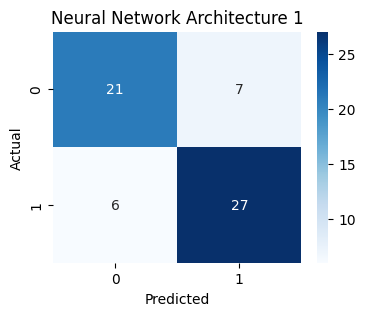

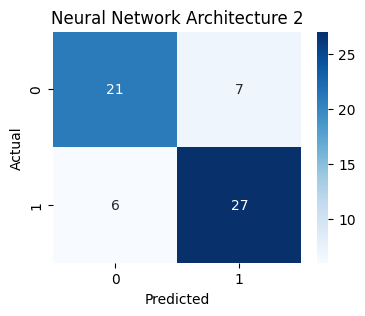

In [16]:
for result, predictions in [
    (nn_result_1, nn_pred_1),
    (nn_result_2, nn_pred_2)
]:
    cm = confusion_matrix(y_test, predictions)

    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(result["Model"])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# Final Model Comparison

The performance of all classifiers was compared using:

- Accuracy
- Precision
- Recall
- F1-score

The best-performing classifier was selected based on overall performance.

In [17]:
nn_results_df = pd.DataFrame([nn_result_1, nn_result_2])

final_results_df = pd.concat(
    [results_df, feature_selection_df, nn_results_df],
    ignore_index=True
)

comparison_columns = ["Model", "Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]
display(final_results_df[comparison_columns].sort_values(by="F1-score", ascending=False))


,Model,Best Parameters,Accuracy,Precision,Recall,F1-score,Confusion Matrix
4,Logistic Regression with Feature Selection,"{'C': 0.1, 'solver': 'lbfgs'}",0.819672,0.823529,0.848485,0.835821,"[[22, 6], [5, 28]]"
0,Logistic Regression,"{'C': 0.01, 'solver': 'lbfgs'}",0.803279,0.783784,0.878788,0.828571,"[[20, 8], [4, 29]]"
2,KNN,"{'n_neighbors': 9, 'weights': 'uniform'}",0.803279,0.783784,0.878788,0.828571,"[[20, 8], [4, 29]]"
3,Random Forest,"{'criterion': 'entropy', 'max_depth': 3, 'n_es...",0.803279,0.800000,0.848485,0.823529,"[[21, 7], [5, 28]]"
6,KNN with Feature Selection,"{'n_neighbors': 9, 'weights': 'uniform'}",0.803279,0.800000,0.848485,0.823529,"[[21, 7], [5, 28]]"
7,Random Forest with Feature Selection,"{'criterion': 'entropy', 'max_depth': 3, 'n_es...",0.786885,0.777778,0.848485,0.811594,"[[20, 8], [5, 28]]"
9,Neural Network Architecture 2,32 -> Dropout -> 16 -> 8 -> output,0.786885,0.794118,0.818182,0.805970,"[[21, 7], [6, 27]]"
8,Neural Network Architecture 1,16 -> 8 -> output,0.786885,0.794118,0.818182,0.805970,"[[21, 7], [6, 27]]"
1,Decision Tree,"{'criterion': 'entropy', 'max_depth': 3}",0.770492,0.743590,0.878788,0.805556,"[[18, 10], [4, 29]]"
5,Decision Tree with Feature Selection,"{'criterion': 'entropy', 'max_depth': 3}",0.754098,0.764706,0.787879,0.776119,"[[20, 8], [7, 26]]"


The best-performing model was identified based mainly on the F1-score, because this metric balances precision and recall. This is important for heart disease prediction, where both false positives and false negatives are relevant.

## K-Fold Cross Validation

A single train-test split can be sensitive to which records happen to be assigned to the test set. To evaluate model stability, 5-fold `StratifiedKFold` cross validation was applied to each classification model. Stratification preserves the class balance in each fold, which is important for heart disease prediction because both positive and negative classes must be represented consistently.

Accuracy, precision, recall and F1-score are reported as mean and standard deviation across folds. A higher mean indicates stronger average performance, while a lower standard deviation indicates more stable behavior across different validation splits.

In [ ]:
import os

os.makedirs("../results", exist_ok=True)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scoring = {
    "Accuracy": "accuracy",
    "Precision": make_scorer(precision_score, zero_division=0),
    "Recall": make_scorer(recall_score, zero_division=0),
    "F1 Score": make_scorer(f1_score, zero_division=0)
}

cross_validation_results = []


def add_cv_summary(model_name, metric_scores):
    summary = {"Model": model_name}

    for metric_name, scores in metric_scores.items():
        summary[f"{metric_name} Mean"] = np.mean(scores)
        summary[f"{metric_name} Std"] = np.std(scores)

    cross_validation_results.append(summary)


for model_name, model in best_models.items():
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", clone(model))
    ])

    scores = cross_validate(
        pipeline,
        X,
        y,
        cv=cv,
        scoring=cv_scoring,
        n_jobs=-1
    )

    add_cv_summary(
        model_name,
        {metric: scores[f"test_{metric}"] for metric in cv_scoring}
    )


for model_name, model in best_feature_selection_models.items():
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("feature_selection", SelectKBest(score_func=f_classif, k=8)),
        ("model", clone(model))
    ])

    scores = cross_validate(
        pipeline,
        X,
        y,
        cv=cv,
        scoring=cv_scoring,
        n_jobs=-1
    )

    add_cv_summary(
        model_name + " with Feature Selection",
        {metric: scores[f"test_{metric}"] for metric in cv_scoring}
    )


def build_neural_network_1(input_dim):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(16, activation="relu"),
        Dense(8, activation="relu"),
        Dense(1, activation="sigmoid")
    ])
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model


def build_neural_network_2(input_dim):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(32, activation="relu"),
        Dropout(0.3),
        Dense(16, activation="relu"),
        Dense(8, activation="relu"),
        Dense(1, activation="sigmoid")
    ])
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model


def evaluate_neural_network_cv(model_name, build_model):
    metric_scores = {
        "Accuracy": [],
        "Precision": [],
        "Recall": [],
        "F1 Score": []
    }

    for fold, (train_index, test_index) in enumerate(cv.split(X, y), start=1):
        X_train_fold = X.iloc[train_index]
        X_test_fold = X.iloc[test_index]
        y_train_fold = y.iloc[train_index]
        y_test_fold = y.iloc[test_index]

        fold_scaler = StandardScaler()
        X_train_fold_scaled = fold_scaler.fit_transform(X_train_fold)
        X_test_fold_scaled = fold_scaler.transform(X_test_fold)

        nn_model = build_model(X_train_fold_scaled.shape[1])
        nn_model.fit(
            X_train_fold_scaled,
            y_train_fold,
            epochs=50,
            batch_size=16,
            verbose=0
        )

        y_pred_fold = (nn_model.predict(X_test_fold_scaled, verbose=0).ravel() > 0.5).astype("int32")

        metric_scores["Accuracy"].append(accuracy_score(y_test_fold, y_pred_fold))
        metric_scores["Precision"].append(precision_score(y_test_fold, y_pred_fold, zero_division=0))
        metric_scores["Recall"].append(recall_score(y_test_fold, y_pred_fold, zero_division=0))
        metric_scores["F1 Score"].append(f1_score(y_test_fold, y_pred_fold, zero_division=0))

    add_cv_summary(model_name, metric_scores)


evaluate_neural_network_cv("Neural Network Architecture 1", build_neural_network_1)
evaluate_neural_network_cv("Neural Network Architecture 2", build_neural_network_2)

cross_validation_df = pd.DataFrame(cross_validation_results)
cross_validation_df = cross_validation_df.sort_values(
    by="F1 Score Mean",
    ascending=False
).reset_index(drop=True)

cross_validation_df.to_csv("../results/cross_validation_results.csv", index=False)
display(cross_validation_df)


Cross-validation helps identify whether a model performs consistently or depends heavily on one favorable split. Models with similar mean scores can be compared using their standard deviations: lower variation suggests more reliable performance across patient subsets.

For this project, F1-score stability is especially useful because it balances precision and recall. A stable F1-score means the model is more consistently balancing false positives and false negatives, which matters in a heart disease risk screening context.

## Learning Curve Analysis

Learning curves show how model performance changes as the amount of training data increases. Each plot compares the training score with the validation score across different training-set sizes using 5-fold stratified cross validation.

The analysis uses F1-score because it balances precision and recall, which is important for heart disease prediction. A large gap between training and validation scores suggests overfitting. Low training and validation scores suggest underfitting. Similar high scores suggest better generalization.

In [ ]:
import os

os.makedirs("../results", exist_ok=True)

learning_curve_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
learning_curve_train_sizes = np.linspace(0.2, 1.0, 5)


def plot_sklearn_learning_curve(model_name, estimator, output_filename):
    train_sizes_abs, train_scores, validation_scores = learning_curve(
        estimator=estimator,
        X=X,
        y=y,
        train_sizes=learning_curve_train_sizes,
        cv=learning_curve_cv,
        scoring=make_scorer(f1_score, zero_division=0),
        n_jobs=-1
    )

    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    validation_mean = validation_scores.mean(axis=1)
    validation_std = validation_scores.std(axis=1)

    plt.figure(figsize=(8, 5))
    plt.plot(train_sizes_abs, train_mean, marker="o", label="Training F1-score")
    plt.fill_between(train_sizes_abs, train_mean - train_std, train_mean + train_std, alpha=0.15)
    plt.plot(train_sizes_abs, validation_mean, marker="o", label="Validation F1-score")
    plt.fill_between(
        train_sizes_abs,
        validation_mean - validation_std,
        validation_mean + validation_std,
        alpha=0.15
    )
    plt.xlabel("Training Set Size")
    plt.ylabel("F1-score")
    plt.title(f"Learning Curve - {model_name}")
    plt.ylim(0, 1.05)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"../results/{output_filename}", dpi=300, bbox_inches="tight")
    plt.show()

    return pd.DataFrame({
        "Model": model_name,
        "Training Size": train_sizes_abs,
        "Training F1 Mean": train_mean,
        "Training F1 Std": train_std,
        "Validation F1 Mean": validation_mean,
        "Validation F1 Std": validation_std
    })


logistic_learning_curve_df = plot_sklearn_learning_curve(
    "Logistic Regression",
    Pipeline([
        ("scaler", StandardScaler()),
        ("model", clone(best_models["Logistic Regression"]))
    ]),
    "logistic_learning_curve.png"
)

randomforest_learning_curve_df = plot_sklearn_learning_curve(
    "Random Forest",
    Pipeline([
        ("scaler", StandardScaler()),
        ("model", clone(best_models["Random Forest"]))
    ]),
    "randomforest_learning_curve.png"
)


def build_learning_curve_neural_network(input_dim):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(16, activation="relu"),
        Dense(8, activation="relu"),
        Dense(1, activation="sigmoid")
    ])
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model


def neural_network_learning_curve():
    train_sizes_abs = []
    train_score_rows = []
    validation_score_rows = []

    for train_fraction in learning_curve_train_sizes:
        fold_train_scores = []
        fold_validation_scores = []
        current_train_size = None

        for train_index, validation_index in learning_curve_cv.split(X, y):
            train_pool_X = X.iloc[train_index]
            train_pool_y = y.iloc[train_index]
            validation_X = X.iloc[validation_index]
            validation_y = y.iloc[validation_index]

            if train_fraction < 1.0:
                subset_X, _, subset_y, _ = train_test_split(
                    train_pool_X,
                    train_pool_y,
                    train_size=train_fraction,
                    random_state=42,
                    stratify=train_pool_y
                )
            else:
                subset_X = train_pool_X
                subset_y = train_pool_y

            current_train_size = len(subset_X)

            fold_scaler = StandardScaler()
            subset_X_scaled = fold_scaler.fit_transform(subset_X)
            validation_X_scaled = fold_scaler.transform(validation_X)

            nn_model = build_learning_curve_neural_network(subset_X_scaled.shape[1])
            nn_model.fit(
                subset_X_scaled,
                subset_y,
                epochs=50,
                batch_size=16,
                verbose=0
            )

            train_predictions = (nn_model.predict(subset_X_scaled, verbose=0).ravel() > 0.5).astype("int32")
            validation_predictions = (nn_model.predict(validation_X_scaled, verbose=0).ravel() > 0.5).astype("int32")

            fold_train_scores.append(f1_score(subset_y, train_predictions, zero_division=0))
            fold_validation_scores.append(f1_score(validation_y, validation_predictions, zero_division=0))

        train_sizes_abs.append(current_train_size)
        train_score_rows.append(fold_train_scores)
        validation_score_rows.append(fold_validation_scores)

    train_scores = np.array(train_score_rows)
    validation_scores = np.array(validation_score_rows)
    train_sizes_abs = np.array(train_sizes_abs)

    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    validation_mean = validation_scores.mean(axis=1)
    validation_std = validation_scores.std(axis=1)

    plt.figure(figsize=(8, 5))
    plt.plot(train_sizes_abs, train_mean, marker="o", label="Training F1-score")
    plt.fill_between(train_sizes_abs, train_mean - train_std, train_mean + train_std, alpha=0.15)
    plt.plot(train_sizes_abs, validation_mean, marker="o", label="Validation F1-score")
    plt.fill_between(
        train_sizes_abs,
        validation_mean - validation_std,
        validation_mean + validation_std,
        alpha=0.15
    )
    plt.xlabel("Training Set Size")
    plt.ylabel("F1-score")
    plt.title("Learning Curve - Neural Network")
    plt.ylim(0, 1.05)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig("../results/neuralnetwork_learning_curve.png", dpi=300, bbox_inches="tight")
    plt.show()

    return pd.DataFrame({
        "Model": "Neural Network",
        "Training Size": train_sizes_abs,
        "Training F1 Mean": train_mean,
        "Training F1 Std": train_std,
        "Validation F1 Mean": validation_mean,
        "Validation F1 Std": validation_std
    })


neuralnetwork_learning_curve_df = neural_network_learning_curve()

learning_curve_summary_df = pd.concat(
    [logistic_learning_curve_df, randomforest_learning_curve_df, neuralnetwork_learning_curve_df],
    ignore_index=True
)

display(learning_curve_summary_df)


The Logistic Regression learning curve is useful for checking whether the linear model has enough capacity. If training and validation scores are close but both plateau below the strongest models, the model is likely underfitting because the decision boundary is too simple.

The Random Forest learning curve helps identify overfitting. A high training score with a lower validation score indicates that the ensemble is fitting training patterns more strongly than it generalizes. If the validation curve improves as training size increases, more data or stronger regularization may reduce the gap.

The Neural Network learning curve shows whether the network benefits from additional data and whether its training score separates from validation score. A widening gap suggests overfitting, while low and similar scores suggest underfitting or insufficient training capacity. Stable convergence between the two curves indicates healthier generalization behavior.

## ROC-AUC Evaluation

ROC curves compare each classifier across all probability thresholds by plotting the true positive rate against the false positive rate. The ROC-AUC score summarizes this curve into a single value: higher scores indicate better separation between patients with and without heart disease.

The comparison below includes the classical models, the same models after feature selection, and both neural network architectures.

In [ ]:
import os

os.makedirs("../results", exist_ok=True)

roc_score_sets = {
    **model_roc_scores,
    **feature_selection_roc_scores,
    "Neural Network Architecture 1": nn_score_1,
    "Neural Network Architecture 2": nn_score_2
}

plt.figure(figsize=(10, 8))

for model_name, y_score in roc_score_sets.items():
    fpr, tpr, _ = roc_curve(y_test, y_score)
    auc_score = roc_auc_score(y_test, y_score)
    plt.plot(fpr, tpr, linewidth=2, label=f"{model_name} (AUC = {auc_score:.3f})")

plt.plot([0, 1], [0, 1], "k--", label="Random baseline")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Classification Models")
plt.legend(loc="lower right", fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../results/roc_curves.png", dpi=300, bbox_inches="tight")
plt.show()

metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]
model_comparison_plot_df = final_results_df[["Model"] + metrics_to_plot].melt(
    id_vars="Model",
    value_vars=metrics_to_plot,
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(14, 7))
sns.barplot(
    data=model_comparison_plot_df,
    x="Model",
    y="Score",
    hue="Metric"
)
plt.ylim(0, 1.05)
plt.xlabel("Model")
plt.ylabel("Score")
plt.title("Model Comparison Across Evaluation Metrics")
plt.xticks(rotation=35, ha="right")
plt.legend(title="Metric", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("../results/model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

display(final_results_df[["Model"] + metrics_to_plot].sort_values(by="ROC-AUC", ascending=False))


The ROC comparison complements accuracy, precision, recall and F1-score by evaluating ranking quality across thresholds instead of only the default classification cutoff. Models with higher ROC-AUC values are better at assigning higher risk scores to patients who truly have heart disease.

The grouped model comparison chart makes it easier to identify trade-offs. A model may have strong recall but lower precision, or strong F1-score but weaker ROC-AUC, so the final model choice should consider the clinical goal and the cost of false negatives versus false positives.

# Clustering Analysis

Before clustering, the target variable was removed to ensure unsupervised learning.

K-Means clustering was evaluated for `k` values from 2 to 10. For each cluster count, the notebook calculates inertia for the Elbow Method, the Silhouette Score for cluster separation quality, and two external validation metrics against the actual heart disease labels: Adjusted Rand Index (ARI) and Normalized Mutual Information (NMI).


,k,Silhouette Score
0,2,0.168272
1,3,0.117103
2,4,0.120918
3,5,0.118705
4,6,0.111974
5,7,0.126136


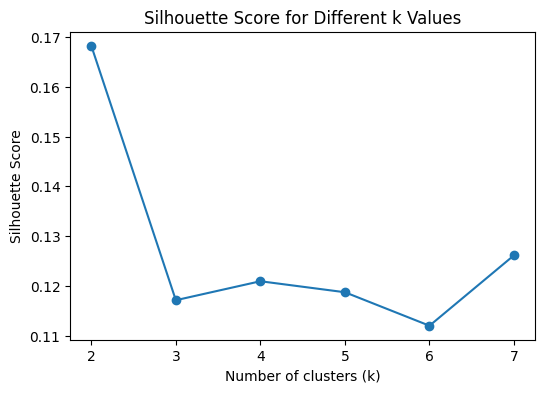

In [18]:
import os

os.makedirs("../results", exist_ok=True)

clustering_results = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(X_train_scaled)

    clustering_results.append({
        "k": k,
        "Inertia": kmeans.inertia_,
        "Silhouette Score": silhouette_score(X_train_scaled, clusters),
        "Adjusted Rand Index": adjusted_rand_score(y_train, clusters),
        "Normalized Mutual Information": normalized_mutual_info_score(y_train, clusters)
    })

clustering_evaluation_df = pd.DataFrame(clustering_results)

best_cluster_row = clustering_evaluation_df.loc[
    clustering_evaluation_df["Silhouette Score"].idxmax()
]
best_k = int(best_cluster_row["k"])

clustering_evaluation_df.to_csv("../results/clustering_evaluation.csv", index=False)

display(clustering_evaluation_df)
print("Best cluster count based on Silhouette Score:", best_k)
print("Best Silhouette Score:", best_cluster_row["Silhouette Score"])
print("Adjusted Rand Index for best k:", best_cluster_row["Adjusted Rand Index"])
print("Normalized Mutual Information for best k:", best_cluster_row["Normalized Mutual Information"])

plt.figure(figsize=(8, 5))
plt.plot(clustering_evaluation_df["k"], clustering_evaluation_df["Inertia"], marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means")
plt.xticks(clustering_evaluation_df["k"])
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../results/elbow_method.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(
    clustering_evaluation_df["k"],
    clustering_evaluation_df["Silhouette Score"],
    marker="o",
    color="#2f6f8f"
)
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores for K-Means")
plt.xticks(clustering_evaluation_df["k"])
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../results/silhouette_scores.png", dpi=300, bbox_inches="tight")
plt.show()


## K-Means Clustering with Automatically Selected k

The best cluster count is selected using the highest Silhouette Score. This prioritizes compact, well-separated clusters without using the target labels during cluster selection.


In [19]:
best_kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
clusters = best_kmeans.fit_predict(X_train_scaled)

ari_score = adjusted_rand_score(y_train, clusters)
nmi_score = normalized_mutual_info_score(y_train, clusters)

print("Selected k:", best_k)
print("Adjusted Rand Index:", ari_score)
print("Normalized Mutual Information:", nmi_score)


Adjusted Rand Index: 0.41101374337816227


## PCA Visualization of Selected Clusters

PCA was used to reduce dimensionality and visualize the automatically selected K-Means clusters in two dimensions.


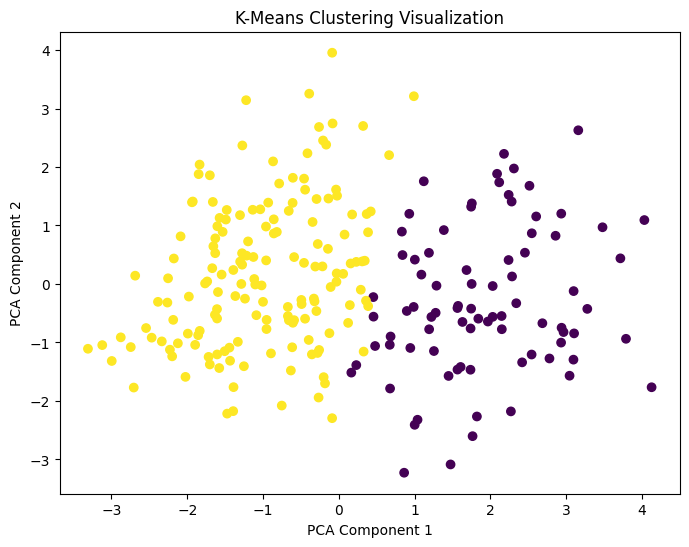

In [20]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_train_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap="viridis")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title(f"K-Means Clustering Visualization (k = {best_k})")
plt.colorbar(label="Cluster")
plt.tight_layout()
plt.show()


The clustering results were compared with the true class labels using Adjusted Rand Index and Normalized Mutual Information. ARI measures how closely the cluster assignments match the actual labels after correcting for chance, while NMI measures the amount of shared information between the discovered clusters and the true classes.


## Clustering Findings

The Elbow Method and Silhouette Score plots provide complementary views of cluster quality. The elbow curve shows how inertia decreases as more clusters are added, while the Silhouette Score identifies the cluster count with the strongest separation. The automatically selected `best_k` is based on the highest Silhouette Score. ARI and NMI are reported separately because they compare the unsupervised cluster assignments with the known heart disease labels, which are not used by K-Means during training.


## Save Results and Best Classical Model

In [21]:
import os

os.makedirs("../results", exist_ok=True)
os.makedirs("../models", exist_ok=True)

final_results_df.to_csv("../results/final_model_results.csv", index=False)

best_classical_model_name = results_df.sort_values(by="F1-score", ascending=False).iloc[0]["Model"]
best_classical_model = best_models[best_classical_model_name]

joblib.dump(best_classical_model, "../models/best_classical_model.pkl")
joblib.dump(scaler, "../models/scaler.pkl")

print("Best classical model:", best_classical_model_name)

Best classical model: Logistic Regression


## Automated ML Report

After training and saving the evaluation outputs, an automated PDF report is generated. The report combines the dataset summary, model comparison table, confusion matrices, ROC curves, clustering evaluation, feature importance analysis and best model summary into a single file.

In [ ]:
import sys
from pathlib import Path

ml_root = Path("..").resolve()
if str(ml_root) not in sys.path:
    sys.path.append(str(ml_root))

from generate_ml_report import generate_report

report_path = generate_report()
print("ML report saved to:", report_path)


# Conclusion

Several machine learning approaches were evaluated for heart disease prediction.

Classical machine learning models, neural networks and clustering techniques were implemented and compared.

The results show that machine learning can be used to support heart disease prediction based on clinical and demographic patient data. The final comparison table helps identify which model achieved the best performance according to accuracy, precision, recall and F1-score.